In [8]:
#Generate dataset
import sys
import os
import numpy as np
sys.path.append(os.path.abspath('..')) 
from cpbge.data import generate_synthetic_data_2node, generate_synthetic_data_4node

num_individuals = 2
num_timepoints = 100
all_data = []
all_true_cps = []   # True change points (optional, for validation)

def generate_synthetic_data_2node_multicps(num_time_points=100, epsilon=0.5, snr=50):
    """Modified: 2-node network (X → X and X → Y) with 5 change points"""
    np.random.seed(42)
    m = num_time_points
    X = np.zeros(m)
    Y = np.zeros(m)
    phi_X = np.random.normal(0, 1, m)
    phi_Y = np.random.normal(0, 1, m)

    X[0] = np.random.normal(0, 1)
    beta = np.ones(m)

    # Define 5 equal segments
    segment_edges = np.linspace(0, m, 6, dtype=int)  # 6 points = 5 segments
    change_points = segment_edges[1:-1]  # inner edges are the CPs

    # Assign different beta values to each segment
    beta[segment_edges[0]:segment_edges[1]] = -1
    beta[segment_edges[1]:segment_edges[2]] = -0.5
    beta[segment_edges[2]:segment_edges[3]] = 0
    beta[segment_edges[3]:segment_edges[4]] = 0.5
    beta[segment_edges[4]:segment_edges[5]] = 1

    # Generate X (autoregressive)
    for t in range(1, m):
        X[t] = np.sqrt(1 - epsilon ** 2) * X[t - 1] + epsilon * phi_X[t]

    # Scale noise
    sigma_beta_X = np.std(beta * X)
    c = sigma_beta_X / snr

    # Generate Y (influenced by beta * X + noise)
    for t in range(m - 1):
        Y[t + 1] = beta[t] * X[t] + c * phi_Y[t + 1]

    data = np.vstack([X, Y])
    true_cps = [change_points.tolist(), change_points.tolist()]  # CPs for both X and Y
    return data, true_cps


# Uncomment the next line to generate a 4-node dataset
# data, true_cps = generate_synthetic_data_4node(num_time_points=num_timepoints)
# node_names = ["X", "Y", "Z", "W"]
# Uncomment the next lines to generate a 2-node dataset
# data, true_cps = generate_synthetic_data_2node_multicps(num_time_points=num_timepoints)
# node_names = ["X", "Y"]

for i in range(num_individuals):
    data_i, true_cps_i = generate_synthetic_data_2node_multicps(num_timepoints)
    all_data.append(data_i)
    all_true_cps.append(true_cps_i)

node_names = ["X", "Y"]

  0%|          | 0/2 [00:00<?, ?it/s]


=== Individual 0 ===
Learned Edge Probabilities (edges with prob > 0.5):
  Edge X → X: 1.000
  Edge X → Y: 1.000
  Node X: filtered changepoints = [72], (K = 2)
  Node Y: filtered changepoints = [32, 53], (K = 3)
Learned Change Points: [[72], [32, 53]]


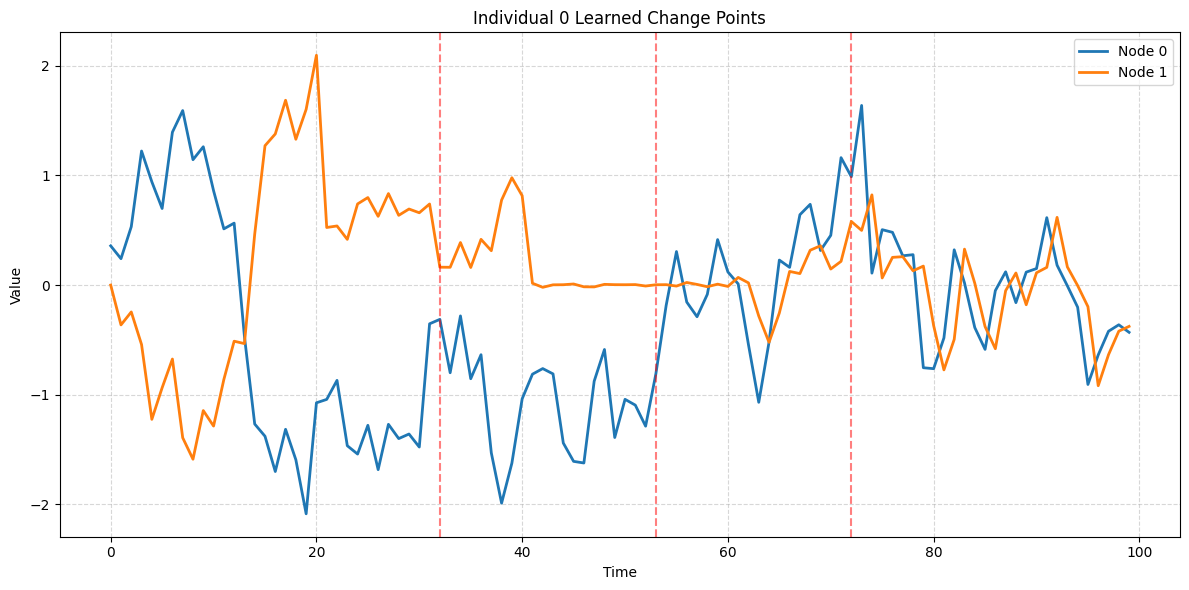

 50%|█████     | 1/2 [01:44<01:44, 104.38s/it]


=== Individual 1 ===
Learned Edge Probabilities (edges with prob > 0.5):
  Edge X → X: 1.000
  Edge X → Y: 1.000
  Node X: filtered changepoints = [], (K = 1)
  Node Y: filtered changepoints = [32, 56], (K = 3)
Learned Change Points: [[], [32, 56]]


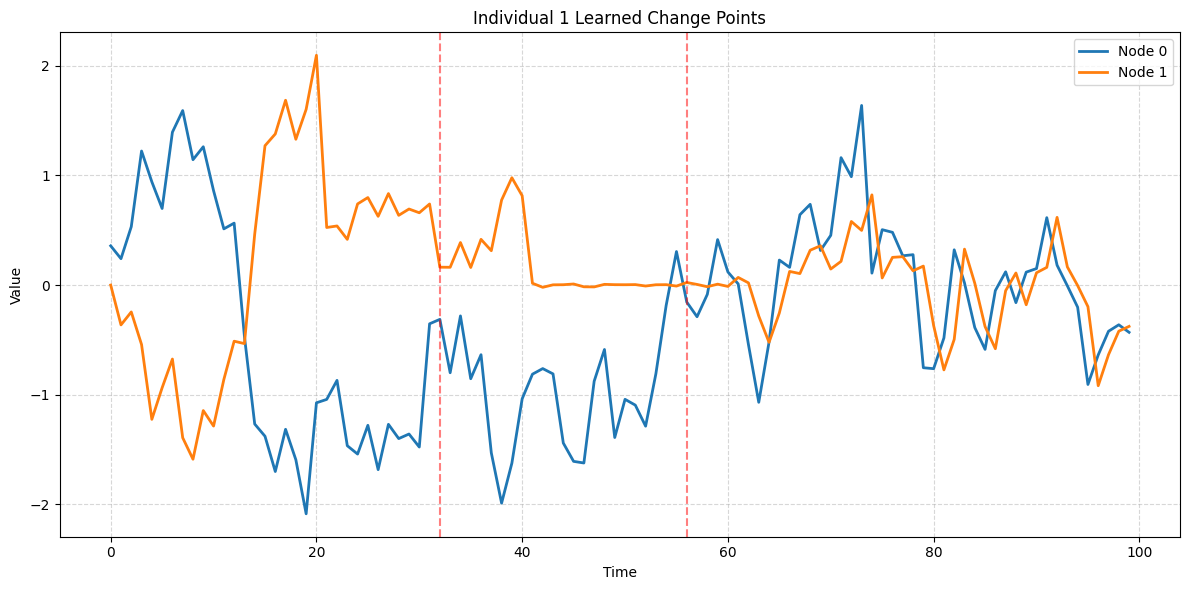

100%|██████████| 2/2 [03:32<00:00, 106.41s/it]


In [9]:
#Find change points
# This script performs MCMC inference on synthetic data, identifies change points,
# and splits the data into segments based on these change points.
import pandas as pd
from cpbge.mcmc import MCMC
from cpbge.plotting import plot_time_series_with_changepoints
from collections import defaultdict
from tqdm import tqdm  # optional for progress bar


def split_dataframe_at_change_points(df, change_points):
    """
    Splits a DataFrame into segments at the given change points.

    Parameters:
        df (pd.DataFrame): The DataFrame to split.
        change_points (list of lists): Nested list of change points (e.g., [[33, 65], [33, 65]])

    Returns:
        list of pd.DataFrame: A list of DataFrame segments.
    """
    # Step 1: Flatten and deduplicate change points
    flat_points = sorted(set(point for sublist in change_points for point in sublist))
    
    # Step 2: Add start and end bounds
    indices = [0] + flat_points + [len(df)]
    
    # Step 3: Split the DataFrame
    segments = [df.iloc[indices[i]:indices[i+1]] for i in range(len(indices) - 1)]
    
    return segments

def filter_close_changepoints(cp_list, min_distance, total_length):
    """
    Remove changepoints that would result in segments shorter than min_distance,
    including the first and last segments.

    Parameters:
        cp_list (list[int]): Sorted list of changepoint indices.
        min_distance (int): Minimum allowed segment length.
        total_length (int): Total length of the time series.

    Returns:
        list[int]: Filtered changepoints.
    """
    if not cp_list:
        return []

    cp_list = sorted(cp_list)
    filtered = []

    prev_cp = 0
    for cp in cp_list:
        if cp - prev_cp >= min_distance:
            filtered.append(cp)
            prev_cp = cp
        # else: skip cp because the segment would be too short

    # Ensure final segment is also long enough
    if filtered and total_length - filtered[-1] < min_distance:
        filtered.pop()

    return filtered

all_edge_probs = []
all_allocations = []
all_K = []
all_cps = []

def print_learned_structure(edge_probs, mean_K, allocation, node_names=None, min_segment_length=5):
    """Prints edges and change points using readable node labels."""
    if node_names is None:
        node_names = [str(i) for i in range(len(mean_K))]

    print("Learned Edge Probabilities (edges with prob > 0.5):")
    for (u, v), prob in edge_probs.items():
        if prob > 0.5:
            print(f"  Edge {node_names[u]} → {node_names[v]}: {prob:.3f}")

    T = allocation.shape[1]
    cps = [[] for _ in range(allocation.shape[0])]

    for node in range(allocation.shape[0]):
        raw_cp = np.where(allocation[node, 1:] != allocation[node, :-1])[0].tolist()
        filtered_cp = filter_close_changepoints(raw_cp, min_segment_length, T)
        cps[node].extend(filtered_cp)

        print(f"  Node {node_names[node]}: filtered changepoints = {filtered_cp}, (K = {len(filtered_cp) + 1})")

    return cps

i=0

for data_i in tqdm(all_data):
    print(f"\n=== Individual {i} ===")
    
    model = MCMC(num_nodes=data_i.shape[0], max_segments=10)
    edge_probs, mean_K, allocation, samples = model.mcmc_inference(
        data_i, num_iterations=500000, burn_in=1000
    )

    cps_per_node = print_learned_structure(edge_probs, mean_K, allocation, node_names=node_names, min_segment_length=5)
    #cps_per_node = [cps_per_node] * len(node_names)
    print("Learned Change Points:", cps_per_node)
    # Collect outputs
    all_edge_probs.append(edge_probs)
    all_allocations.append(allocation)
    all_K.append(mean_K)
    all_cps.append(cps_per_node)

    plot_time_series_with_changepoints(data_i, cps_per_node, title=f"Individual {i} Learned Change Points")
    i += 1


    

In [10]:
print(all_cps)

[[[72], [32, 53]], [[], [32, 56]]]


In [11]:
from collections import defaultdict

def extract_bayesian_structure(edge_probs, node_names, threshold=0.5):
    """Builds child-to-parents mapping for nodes with edge probability > threshold."""
    child_parents = defaultdict(list)
    for (u, v), prob in edge_probs.items():
        if prob > threshold:
            child_parents[v].append(u)

    bayesian_structure = [
        [node_names[child], [node_names[parent] for parent in parents]]
        for child, parents in child_parents.items()
    ]
    return bayesian_structure


def apply_temporal_shift(df, bayesian_structure):
    """Adds t-1 columns for self-loops in the Bayesian structure."""
    updated_structure = []

    for child, parents in bayesian_structure:
        new_parents = []
        for parent in parents:
            if parent == child:
                lagged_col = f"{parent}_t-1"
                if lagged_col not in df.columns:
                    print(f"Creating lagged column for self-parenting node: {child}")
                    df[lagged_col] = df[parent].shift(1)
                new_parents.append(lagged_col)
            else:
                new_parents.append(parent)
        updated_structure.append([child, new_parents])

    df = df.dropna().reset_index(drop=True)
    return df, updated_structure

all_structures = {}
all_shifted_data = {}
all_variable_segments = {}

for i, (data_i, edge_probs_i, learnt_cps_i) in enumerate(zip(all_data, all_edge_probs, all_cps)):
    indiv_id = f"indiv_{i}"
    print(f"\n=== Processing {indiv_id} ===")

    # Step 1: Extract structure
    structure = extract_bayesian_structure(edge_probs_i, node_names)
    print("Structure:", structure)

    # Step 2: Create DataFrame
    data_df = pd.DataFrame(data_i.T, columns=node_names)

    # Step 3: Apply temporal shift
    shifted_df, updated_structure = apply_temporal_shift(data_df.copy(), structure)
    print("Updated Structure:", updated_structure)

    # Step 4: Split per variable using its own change points
    variable_segments = {}
    for var_idx, var_cps in enumerate(learnt_cps_i):
        var_name = node_names[var_idx]

        # Get parents for this variable from the structure
        parents = next((parents for child, parents in updated_structure if child == var_name), [])

        # Identify required columns: var_name, var_name_t-1 (if exists), and parents
        required_cols = [col for col in shifted_df.columns if col.startswith(var_name)]  # e.g., 'Y', 'Y_t-1'
        for p in parents:
            if p not in required_cols:
                required_cols.append(p)

        # Get change points for this variable and create segments
        cps = sorted(set([0] + var_cps + [len(shifted_df)]))  # Add start & end

        # Now build segments, shifting indices back by 1 for lagged variables (_t-1)
        segments = []
        for i_cp in range(len(cps) - 1):
            start_idx = cps[i_cp]
            end_idx = cps[i_cp + 1]

            # For lagged variables, we shift the segment window one step earlier
            if var_name.endswith("_t-1"):
                start_idx = max(start_idx - 1, 0)
                end_idx = max(end_idx - 1, 0)

            seg = shifted_df[required_cols].iloc[start_idx:end_idx].copy()
            segments.append(seg)

        variable_segments[var_name] = segments

        for j, seg in enumerate(segments):
            print(f"{indiv_id} - {var_name} - Segment {j} shape: {seg.shape}")

    # Save results
    all_structures[indiv_id] = updated_structure
    all_shifted_data[indiv_id] = shifted_df
    all_variable_segments[indiv_id] = variable_segments


=== Processing indiv_0 ===
Structure: [['X', ['X']], ['Y', ['X']]]
Creating lagged column for self-parenting node: X
Updated Structure: [['X', ['X_t-1']], ['Y', ['X']]]
indiv_0 - X - Segment 0 shape: (72, 2)
indiv_0 - X - Segment 1 shape: (27, 2)
indiv_0 - Y - Segment 0 shape: (32, 2)
indiv_0 - Y - Segment 1 shape: (21, 2)
indiv_0 - Y - Segment 2 shape: (46, 2)

=== Processing indiv_1 ===
Structure: [['X', ['X']], ['Y', ['X']]]
Creating lagged column for self-parenting node: X
Updated Structure: [['X', ['X_t-1']], ['Y', ['X']]]
indiv_1 - X - Segment 0 shape: (99, 2)
indiv_1 - Y - Segment 0 shape: (32, 2)
indiv_1 - Y - Segment 1 shape: (24, 2)
indiv_1 - Y - Segment 2 shape: (43, 2)


In [12]:
# Get conditional probability tables (CPTs) for the Bayesian network
# Use DataSynthesizer1 to describe the datasets and convert description to CPTs
from collections import defaultdict
from DataSynthesizer1.DataDescriber import DataDescriber
from DataSynthesizer1.lib.utils import display_bayesian_network
import pandas as pd
import json
import os

epsilon = 1.0

# Structure: grouped_by_var[individual_id][variable] = [df, df, ...]
grouped_by_var = defaultdict(lambda: defaultdict(list))


def parse_conditional_probabilities(cond_probs, structure):
    """Same as your original parsing function"""
    tables = {}
    parent_map = {child: parents[0] if parents else None for child, parents in structure}

    for child_var, value in cond_probs.items():
        parent_var = parent_map.get(child_var)

        if isinstance(value, list):  # Marginal
            df = pd.DataFrame({
                child_var: list(range(len(value))),
                f"P({child_var})": value
            })
            tables[child_var] = df

        elif isinstance(value, dict) and parent_var:  # Conditional
            records = []
            for parent_val, probs in value.items():
                parent_val_index = int(parent_val.strip("[]"))
                row = {parent_var: parent_val_index}
                row.update({
                    f"P({child_var}={i} | {parent_var}={parent_val_index})": p
                    for i, p in enumerate(probs)
                })
                records.append(row)

            df = pd.DataFrame(records)
            tables[child_var] = df

        else:
            raise ValueError(f"Unsupported format for variable '{child_var}'")

    return tables

# Assuming you have a dictionary: all_individual_segments = {indiv_id: [segment1, segment2, ...]}
for indiv_id, var_segments in all_variable_segments.items():
    structure = all_structures[indiv_id]
    print(f"\nProcessing {indiv_id}, using structure: {structure}")
    
    for var_name, segments in var_segments.items():
        for i, segment_partial in enumerate(segments):
            # Get full shifted df slice for time window
            full_shifted_df = all_shifted_data[indiv_id]
            start_idx = segment_partial.index[0]
            end_idx = segment_partial.index[-1] + 1
            segment_full = full_shifted_df.iloc[start_idx:end_idx].copy()

            print(f"Describing {indiv_id} - {var_name} - Segment {i} with full data shape {segment_full.shape}")

            # Filter structure: keep only the entry for var_name (child) and its parents
            filtered_structure = [
                [child, parents] for child, parents in structure if child == var_name
            ]

            print(f"Filtered structure for {indiv_id} - {var_name} - Segment {i}: {filtered_structure}")

            # Save temporary CSV and describe dataset as before
            segment_path = "temp_segment.csv"
            segment_full.to_csv(segment_path, index=False)

            describer = DataDescriber(bayesian_network=filtered_structure, category_threshold=16)
            describer.describe_dataset_in_correlated_attribute_mode(
                segment_path,
                epsilon=epsilon,
                attribute_to_is_candidate_key={col: False for col in segment_full.columns}
            )

            json_filename = f"dataset_description_{indiv_id}_{var_name}_segment_{i}.json"
            describer.save_dataset_description_to_file(json_filename)
            display_bayesian_network(describer.bayesian_network)

            with open(json_filename) as f:
                data = json.load(f)
            os.remove(segment_path)
            os.remove(json_filename)

            tables = parse_conditional_probabilities(data["conditional_probabilities"], filtered_structure)

            for var, df in tables.items():
                df = df[[col for col in df.columns if col.startswith("P(")]]
                grouped_by_var[indiv_id][var].append(df)
                


Processing indiv_0, using structure: [['X', ['X_t-1']], ['Y', ['X']]]
Describing indiv_0 - X - Segment 0 with full data shape (72, 3)
Filtered structure for indiv_0 - X - Segment 0: [['X', ['X_t-1']]]
Constructed Bayesian network:
    X has parents ['X_t-1'].
Describing indiv_0 - X - Segment 1 with full data shape (27, 3)
Filtered structure for indiv_0 - X - Segment 1: [['X', ['X_t-1']]]
Constructed Bayesian network:
    X has parents ['X_t-1'].
Describing indiv_0 - Y - Segment 0 with full data shape (32, 3)
Filtered structure for indiv_0 - Y - Segment 0: [['Y', ['X']]]
Constructed Bayesian network:
    Y has parents ['X'].
Describing indiv_0 - Y - Segment 1 with full data shape (21, 3)
Filtered structure for indiv_0 - Y - Segment 1: [['Y', ['X']]]
Constructed Bayesian network:
    Y has parents ['X'].
Describing indiv_0 - Y - Segment 2 with full data shape (46, 3)
Filtered structure for indiv_0 - Y - Segment 2: [['Y', ['X']]]
Constructed Bayesian network:
    Y has parents ['X'].

Pr

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance

def compute_wasserstein_matrix(series_list, epsilon=1e-8):
    n = len(series_list)
    wd_matrix = np.zeros((n, n))
    labels = [f"Segment_{i}" for i in range(n)]

    # Convert each series to a normalized probability distribution
    distributions = []
    for series in series_list:
        values = series.dropna().values
        if len(values) == 0:
            distributions.append(None)
            continue
        hist, bin_edges = np.histogram(values, bins=30, density=True)
        hist = np.nan_to_num(hist, nan=epsilon)
        hist /= hist.sum() + epsilon
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        distributions.append((bin_centers, hist))

    for i in range(n):
        for j in range(i + 1, n):
            if distributions[i] is None or distributions[j] is None:
                wd = np.nan
            else:
                x1, p1 = distributions[i]
                x2, p2 = distributions[j]
                common_bins = np.linspace(
                    min(x1.min(), x2.min()), max(x1.max(), x2.max()), 100
                )
                p1_interp = np.interp(common_bins, x1, p1, left=0, right=0)
                p2_interp = np.interp(common_bins, x2, p2, left=0, right=0)
                p1_interp /= p1_interp.sum() + epsilon
                p2_interp /= p2_interp.sum() + epsilon
                wd = wasserstein_distance(common_bins, common_bins, p1_interp, p2_interp)

            wd_matrix[i, j] = wd_matrix[j, i] = wd

    return pd.DataFrame(wd_matrix, index=labels, columns=labels)

variables_to_compare = ['X', 'Y', 'X_t-1']

# Collect segments for each variable across all individuals
all_segments_by_var = {var: [] for var in variables_to_compare}
for indiv_id, var_segments in all_variable_segments.items():
    for var in variables_to_compare:
        segs = var_segments.get(var, [])
        print(f"Individual {indiv_id}, variable {var}, number of segments: {len(segs)}")
        
        series_list = []
        for df in segs:
            if var in df.columns:
                series_list.append(df[var])
            else:
                print(f"Warning: segment missing column '{var}' for individual {indiv_id}")

        all_segments_by_var[var].extend(series_list)

for var, seg_list in all_segments_by_var.items():
    print(f"Variable '{var}' total collected segments across all individuals: {len(seg_list)}")

# Compute Wasserstein distance matrices for each variable
wasserstein_distances_all_vars = {}

for var, segments_list in all_segments_by_var.items():
    if len(segments_list) < 2:
        print(f"Not enough segments for variable '{var}' to compute Wasserstein distance.")
        continue
    
    print(f"Computing Wasserstein distance matrix for variable '{var}', total segments: {len(segments_list)}")
    wd_matrix = compute_wasserstein_matrix(segments_list)
    wasserstein_distances_all_vars[var] = wd_matrix

# Now wasserstein_distances_all_vars[var] holds the distance matrix DataFrame for each variable

# Example to print results:
for var, wd_df in wasserstein_distances_all_vars.items():
    print(f"\nWasserstein Distance Matrix for variable '{var}':")
    print(wd_df)

Individual indiv_0, variable X, number of segments: 2
Individual indiv_0, variable Y, number of segments: 3
Individual indiv_0, variable X_t-1, number of segments: 0
Individual indiv_1, variable X, number of segments: 1
Individual indiv_1, variable Y, number of segments: 3
Individual indiv_1, variable X_t-1, number of segments: 0
Variable 'X' total collected segments across all individuals: 3
Variable 'Y' total collected segments across all individuals: 6
Variable 'X_t-1' total collected segments across all individuals: 0
Computing Wasserstein distance matrix for variable 'X', total segments: 3
Computing Wasserstein distance matrix for variable 'Y', total segments: 6
Not enough segments for variable 'X_t-1' to compute Wasserstein distance.

Wasserstein Distance Matrix for variable 'X':
           Segment_0  Segment_1  Segment_2
Segment_0   0.000000   0.582692   0.165798
Segment_1   0.582692   0.000000   0.427692
Segment_2   0.165798   0.427692   0.000000

Wasserstein Distance Matrix fo

In [17]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt

def impute_normalize_flatten(df, prob_cols=None, epsilon=1e-8):
    df_copy = df.copy()
    if prob_cols is None:
        prob_cols = [col for col in df_copy.columns if col.startswith("P(")]
    prob_cols_present = [col for col in prob_cols if col in df_copy.columns]
    df_copy[prob_cols_present] = df_copy[prob_cols_present].fillna(epsilon)
    row_sums = df_copy[prob_cols_present].sum(axis=1)
    df_copy[prob_cols_present] = df_copy[prob_cols_present].div(row_sums, axis=0)
    return df_copy[prob_cols_present].values.flatten()

def compute_wasserstein_matrix_df(tables, epsilon=1e-8):
    prob_cols = [col for col in tables[0].columns if col.startswith("P(")]
    n = len(tables)
    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            dists = []
            for col in prob_cols:
                p_i = tables[i][col].fillna(epsilon).values
                p_j = tables[j][col].fillna(epsilon).values

                # Normalize
                p_i = p_i / (p_i.sum() + epsilon)
                p_j = p_j / (p_j.sum() + epsilon)

                # Create common support
                max_len = max(len(p_i), len(p_j))
                common_support = np.linspace(0, max_len - 1, max_len)

                # Interpolate distributions to common support
                interp_p_i = np.interp(common_support, np.linspace(0, len(p_i) - 1, len(p_i)), p_i, left=0, right=0)
                interp_p_j = np.interp(common_support, np.linspace(0, len(p_j) - 1, len(p_j)), p_j, left=0, right=0)

                # Normalize interpolated distributions
                interp_p_i /= (interp_p_i.sum() + epsilon)
                interp_p_j /= (interp_p_j.sum() + epsilon)

                # Wasserstein distance
                wd = wasserstein_distance(common_support, common_support, interp_p_i, interp_p_j)
                dists.append(wd)

            dist_matrix[i, j] = dist_matrix[j, i] = np.mean(dists)

    return pd.DataFrame(dist_matrix, index=[f"Segment_{i}" for i in range(n)], columns=[f"Segment_{i}" for i in range(n)])

def kmeans_on_segments(tables, n_clusters=3, epsilon=1e-8):
    prob_cols = [col for col in tables[0].columns if col.startswith("P(")]
    flattened_vectors = [impute_normalize_flatten(df, prob_cols, epsilon) for df in tables]
    max_len = max(len(vec) for vec in flattened_vectors)
    padded_vectors = np.array([np.pad(vec, (0, max_len - len(vec)), 'constant') for vec in flattened_vectors])
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(padded_vectors)
    return labels

def hierarchical_clustering(distance_matrix, n_clusters=2):
    condensed = squareform(distance_matrix.values, checks=False)
    Z = linkage(condensed, method='average')
    labels = fcluster(Z, n_clusters, criterion='maxclust')
    return labels, Z

clustering_results_by_var = {}
for variable, segments in all_segments_by_var.items():
    print(f"\n=== Clustering for Variable: {variable} ===")
    
    if len(segments) < 2:
        print("Not enough valid DataFrame segments to cluster. Skipping.")
        continue

    try:
        # K-means clustering
        kmeans_labels = kmeans_on_segments(segments, n_clusters=2)
        print("K-means labels:", kmeans_labels)

        # Wasserstein distance + hierarchical clustering
        dist_matrix = compute_wasserstein_matrix_df(segments)
        hier_labels, linkage_matrix = hierarchical_clustering(dist_matrix, n_clusters=2)
        print("Hierarchical labels:", hier_labels)

        # Store results
        clustering_results_by_var[variable] = {
            "kmeans_labels": kmeans_labels,
            "hierarchical_labels": hier_labels,
            "distance_matrix": dist_matrix,
            "linkage_matrix": linkage_matrix,
        }

        # Optional: plot dendrogram
        plt.figure(figsize=(8, 4))
        dendrogram(linkage_matrix, labels=dist_matrix.index.tolist())
        plt.title(f"Hierarchical Clustering Dendrogram - {variable}")
        plt.show()

    except Exception as e:
        print(f"Error clustering variable '{variable}': {e}")



=== Clustering for Variable: X ===
Error clustering variable 'X': 'Series' object has no attribute 'columns'

=== Clustering for Variable: Y ===
Error clustering variable 'Y': 'Series' object has no attribute 'columns'

=== Clustering for Variable: X_t-1 ===
Not enough valid DataFrame segments to cluster. Skipping.



=== VBGMM Clustering for Individual indiv_0 ===

Variable: X_t-1
ELBO for 1 clusters: 26.4720
ELBO for 2 clusters: 43.8507


/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:653: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


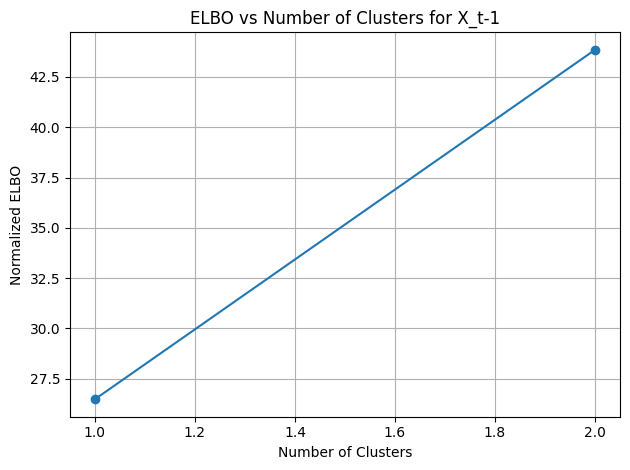

Cluster labels for X_t-1: [0 0]


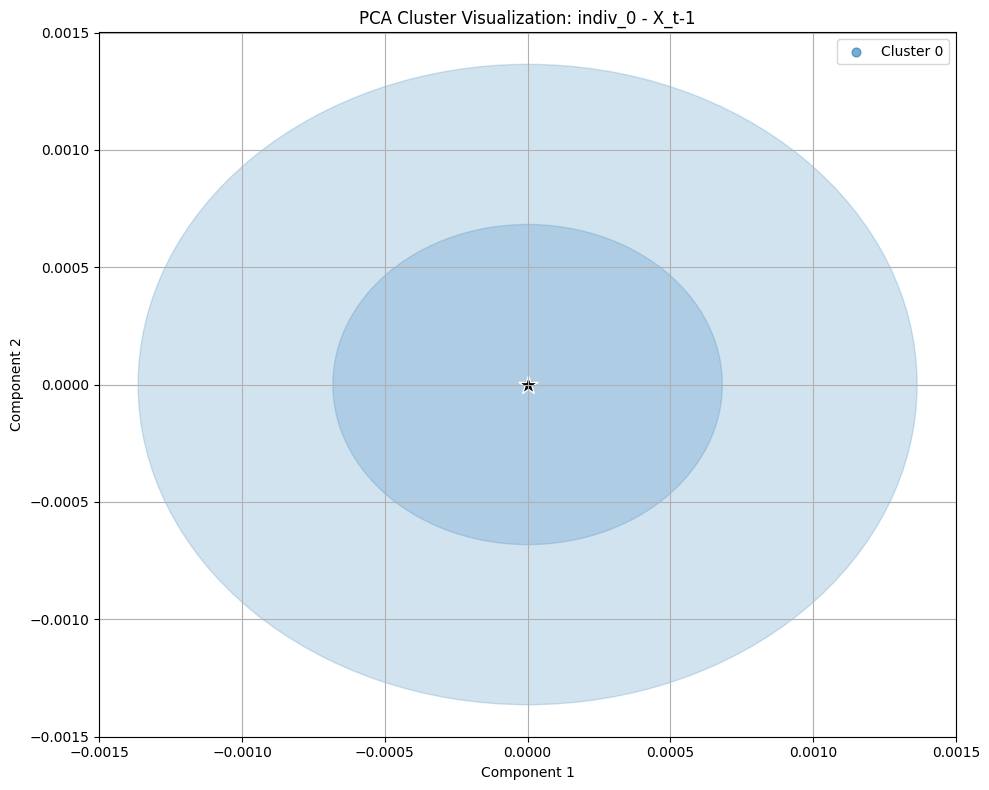


Variable: X
Failed for X with error: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.

Variable: Y
ELBO for 1 clusters: 6.6581
ELBO for 2 clusters: 11.2438
ELBO for 3 clusters: 15.8745


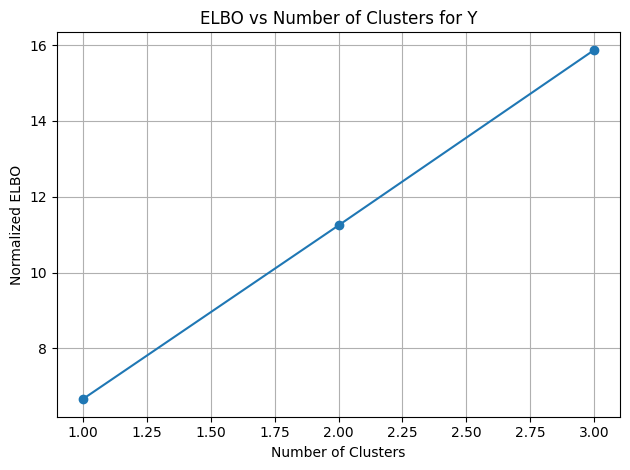

Cluster labels for Y: [0 0 0]


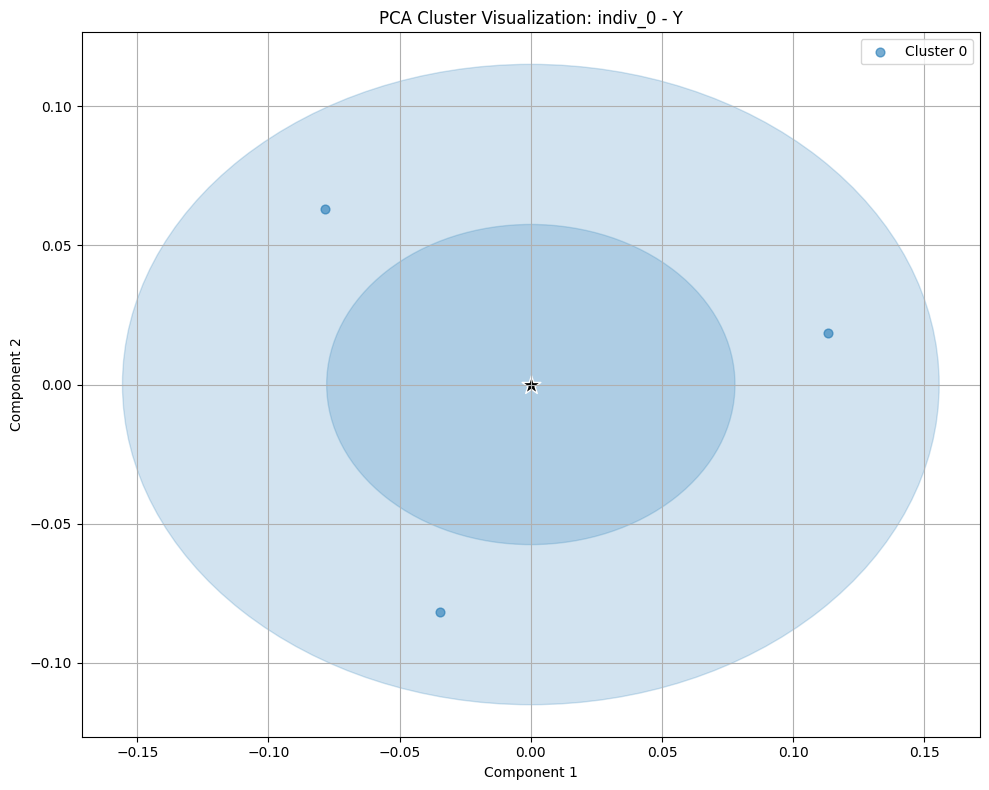


=== VBGMM Clustering for Individual indiv_1 ===
Skipping variable 'X_t-1' (not enough segments)

Variable: X
Failed for X with error: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

Variable: Y
ELBO for 1 clusters: 7.0033
ELBO for 2 clusters: 11.7270
ELBO for 3 clusters: 16.4958


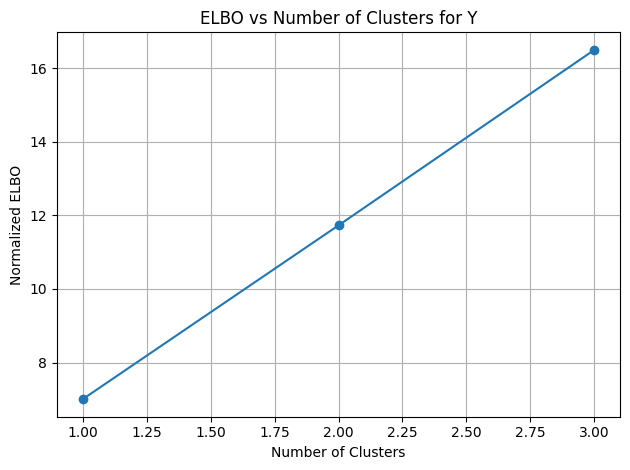

Cluster labels for Y: [0 0 0]


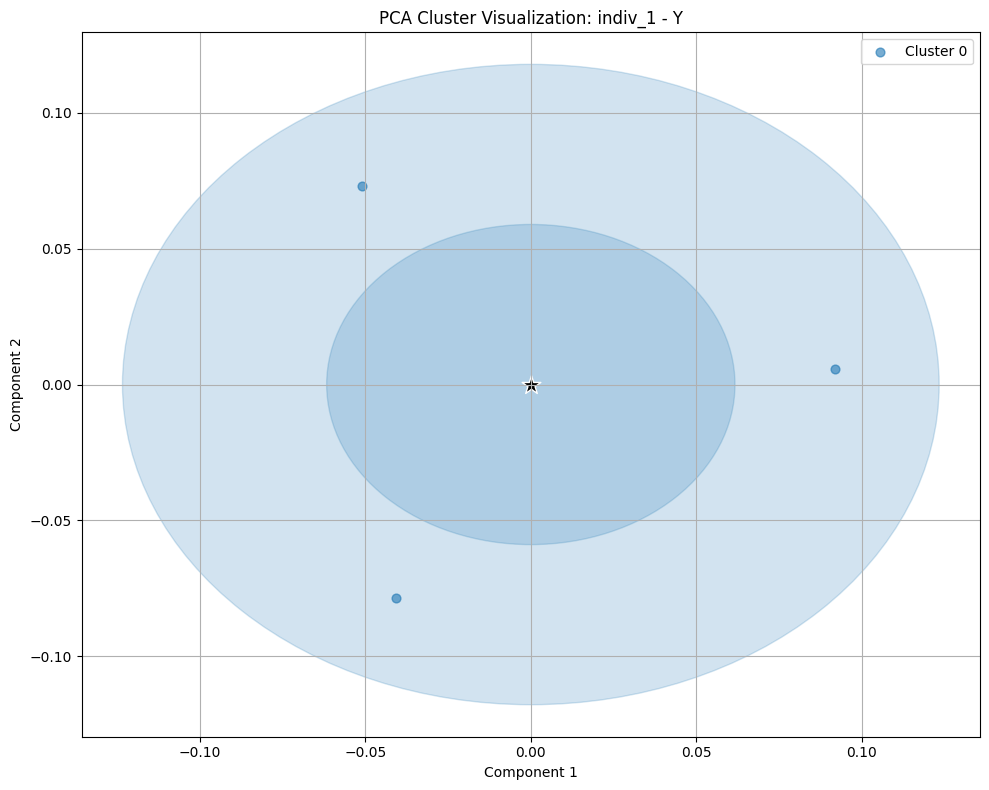

In [ ]:
from sklearn.mixture import BayesianGaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import numpy as np

def fit_vbgmm_elbo(tables, var, epsilon=1e-8, max_clusters=None, n_components=2, random_state=42):
    prob_cols = [col for col in tables[0].columns if col.startswith(f"P({var}")]

    data_vectors = np.array([
        impute_normalize_flatten(df, prob_cols, epsilon) for df in tables
    ])

    if max_clusters is None:
        max_clusters = len(tables)

    reducer = PCA(n_components=n_components)
    reduced_data = reducer.fit_transform(data_vectors)

    elbos = []
    models = []

    for k in range(1, min(max_clusters, len(tables)) + 1):
        model = BayesianGaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
        model.fit(reduced_data)
        elbo = model.lower_bound_ / len(tables)
        elbos.append(elbo)
        models.append(model)
        print(f"ELBO for {k} clusters: {elbo:.4f}")

    # Plot ELBO
    plt.figure()
    plt.plot(range(1, len(elbos) + 1), elbos, marker='o')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Normalized ELBO')
    plt.title(f'ELBO vs Number of Clusters for {var}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    best_idx = np.argmax(elbos)
    best_model = models[best_idx]
    return best_model, best_idx + 1, reduced_data, reducer


def visualize_clusters(tables, labels, model, reducer, reduced_data, title='CPT Cluster Visualization'):
    reduced_means = model.means_
    reduced_covariances = model.covariances_

    plt.figure(figsize=(10, 8))
    palette = sns.color_palette("tab10", np.max(labels) + 1)

    for i in range(model.n_components):
        cluster_points = reduced_data[np.array(labels) == i]
        mean = reduced_means[i]
        cov = reduced_covariances[i]

        if cluster_points.shape[0] == 0:
            continue

        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=40,
                    color=palette[i], label=f"Cluster {i}", alpha=0.6)

        if cov.shape == (2, 2):
            v, w = np.linalg.eigh(cov)
            angle = np.degrees(np.arctan2(*w[:, 0][::-1]))
            for scale in [1, 2]:
                ell = Ellipse(xy=mean, width=2*scale*np.sqrt(v[0]), height=2*scale*np.sqrt(v[1]),
                              angle=angle, color=palette[i], alpha=0.2)
                plt.gca().add_patch(ell)

        plt.scatter(mean[0], mean[1], marker='*', c='black', s=200, edgecolor='white')

    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

# Store clustering results
vbgmm_results = {}

# Run Variational Bayesian Gaussian Mixture Model for each individual and variable
for indiv_id, var_dict in grouped_by_var.items():
    vbgmm_results[indiv_id] = {}
    print(f"\n=== VBGMM Clustering for Individual {indiv_id} ===")

    for var, tables in var_dict.items():
        if not tables or len(tables) < 2:
            print(f"Skipping variable '{var}' (not enough segments)")
            continue

        print(f"\nVariable: {var}")
        try:
            best_model, best_k, reduced_data, reducer = fit_vbgmm_elbo(
                tables, var=var, n_components=2
            )

            labels = best_model.predict(reduced_data)
            print(f"Cluster labels for {var}:", labels)

            visualize_clusters(
                tables=tables,
                labels=labels,
                model=best_model,
                reducer=reducer,
                reduced_data=reduced_data,
                title=f'PCA Cluster Visualization: {indiv_id} - {var}'
            )

            vbgmm_results[indiv_id][var] = {
                "model": best_model,
                "labels": labels,
                "reducer": reducer,
                "reduced_data": reduced_data
            }

        except Exception as e:
            print(f"Failed for {var} with error: {e}")


=== Clustering CPTs for Variable: X_t-1 (All Individuals) ===
ELBO for 1 clusters: 21.5208
ELBO for 2 clusters: 33.0609
ELBO for 3 clusters: 46.0271


/opt/homebrew/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:653: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


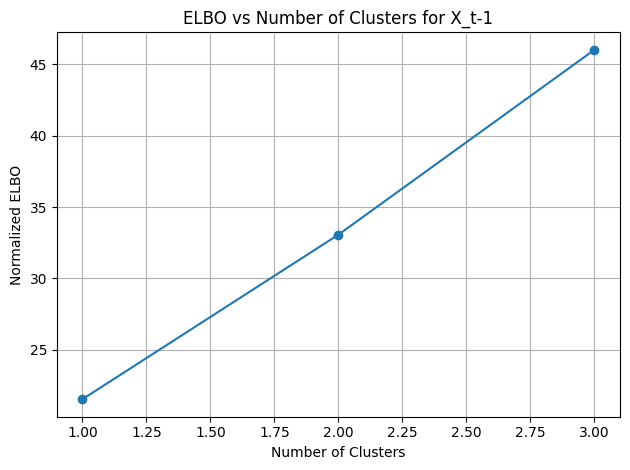

Cluster labels for X_t-1 (all individuals): [0 0 0]


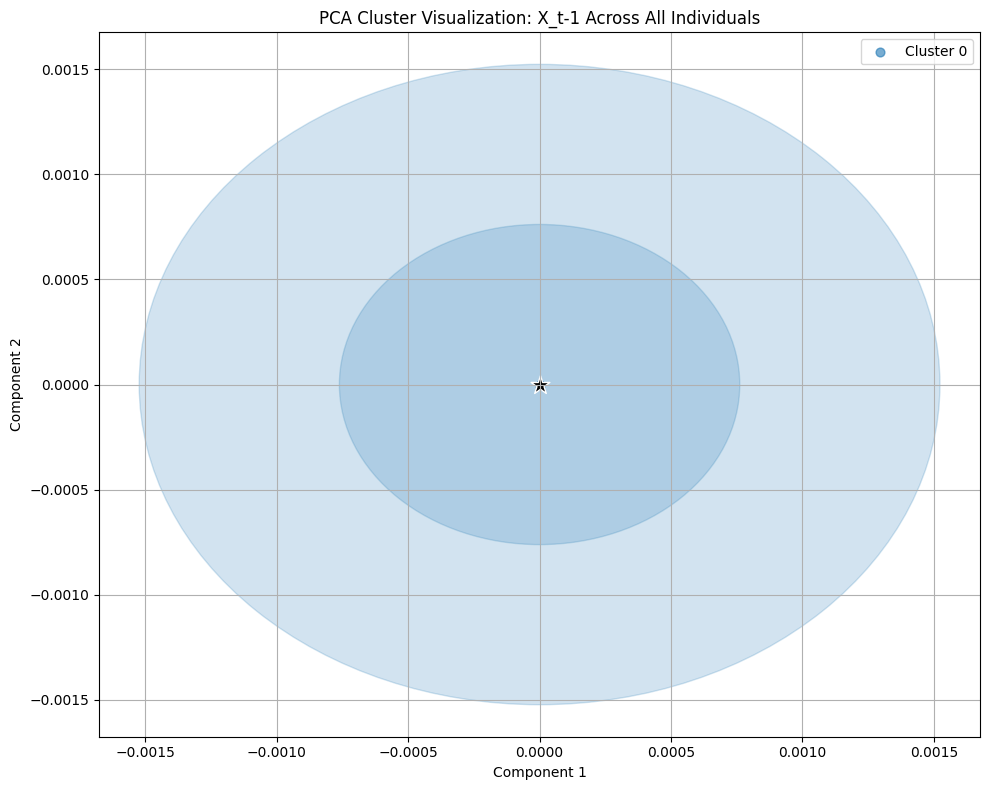


=== Clustering CPTs for Variable: X (All Individuals) ===
Clustering failed for variable 'X' with error: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (9,) + inhomogeneous part.

=== Clustering CPTs for Variable: Y (All Individuals) ===
ELBO for 1 clusters: 5.5758
ELBO for 2 clusters: 7.7571
ELBO for 3 clusters: 10.3162
ELBO for 4 clusters: 12.8022
ELBO for 5 clusters: 15.3278
ELBO for 6 clusters: 17.8869


/opt/homebrew/lib/python3.10/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (5) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


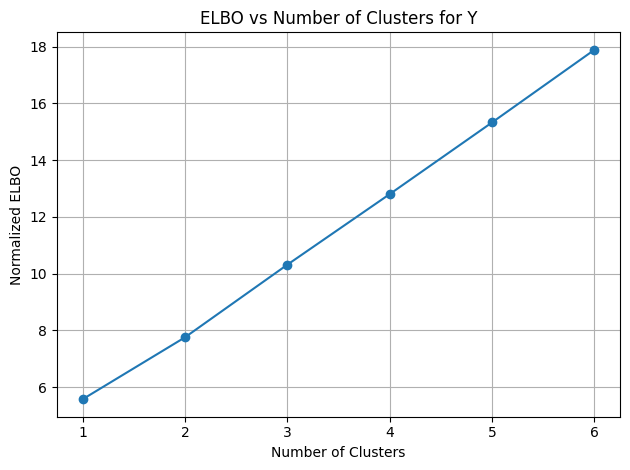

Cluster labels for Y (all individuals): [1 0 0 1 0 0]


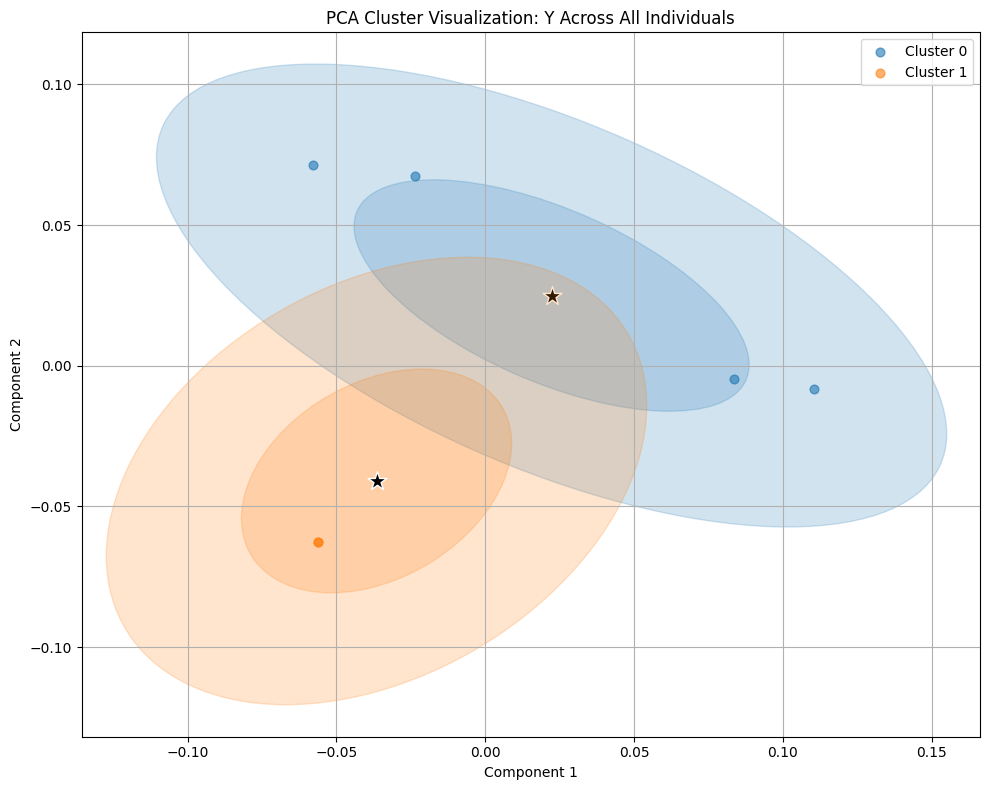

In [16]:
from collections import defaultdict

combined_by_var = defaultdict(list)

# Flatten tables across individuals
for indiv_id, var_dict in grouped_by_var.items():
    for var, tables in var_dict.items():
        combined_by_var[var].extend(tables)
        
vbgmm_results_across_individuals = {}

# Cluster and visualize CPTs per variable across all individuals
for var, tables in combined_by_var.items():
    if not tables or len(tables) < 2:
        print(f"Skipping variable '{var}' (not enough CPTs).")
        continue

    print(f"\n=== Clustering CPTs for Variable: {var} (All Individuals) ===")

    try:
        best_model, best_k, reduced_data, reducer = fit_vbgmm_elbo(
            tables, var=var, n_components=2
        )

        labels = best_model.predict(reduced_data)
        print(f"Cluster labels for {var} (all individuals):", labels)

        visualize_clusters(
            tables=tables,
            labels=labels,
            model=best_model,
            reducer=reducer,
            reduced_data=reduced_data,
            title=f'PCA Cluster Visualization: {var} Across All Individuals'
        )

        vbgmm_results_across_individuals[var] = {
            "model": best_model,
            "labels": labels,
            "reducer": reducer,
            "reduced_data": reduced_data
        }

    except Exception as e:
        print(f"Clustering failed for variable '{var}' with error: {e}")